Importing the Libraries

In [1]:

import os
import random
import shutil
import json
import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Input, Dense, Dropout, concatenate,
    GlobalAveragePooling1D, Layer, Multiply
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

Checking the size of the image in each files

In [2]:
import os
import cv2


datasets = {
    "CT": "Brain Tumor CT scan Images",
    "MRI": "Brain Tumor MRI images"
}


for dataset_name, dataset_path in datasets.items():

    

    # Loop through each class folder
    for class_name in os.listdir(dataset_path):

        class_path = os.path.join(dataset_path, class_name)

        # Check if folder exists
        if os.path.isdir(class_path):

            print(f"\nClass: {class_name}")

            count = 0

            # Loop through images
            for img_name in os.listdir(class_path):

                img_path = os.path.join(class_path, img_name)

                # Read image
                img = cv2.imread(img_path)

                if img is not None:

                    print(f"{img_name} --> {img.shape}")

                    count += 1

                # Show only first 5 images
                if count == 5:
                    break


Class: Healthy
ct_healthy (1).jpg --> (255, 205, 3)
ct_healthy (1).png --> (511, 352, 3)
ct_healthy (10).jpg --> (225, 225, 3)
ct_healthy (10).png --> (315, 230, 3)
ct_healthy (100).jpg --> (512, 512, 3)

Class: Tumor
ct_tumor (1).jpg --> (255, 205, 3)
ct_tumor (1).png --> (957, 821, 3)
ct_tumor (10).jpg --> (255, 205, 3)
ct_tumor (10).png --> (288, 231, 3)
ct_tumor (100).jpg --> (640, 640, 3)

Class: Healthy
mri_healthy (1).jpeg --> (630, 630, 3)
mri_healthy (1).jpg --> (640, 640, 3)
mri_healthy (10).jpg --> (630, 630, 3)
mri_healthy (100).jpg --> (251, 236, 3)
mri_healthy (1000).jpg --> (256, 256, 3)

Class: Tumor
glioma (1).jpg --> (512, 512, 3)
glioma (10).jpg --> (512, 512, 3)
glioma (100).jpg --> (512, 512, 3)
glioma (101).jpg --> (512, 512, 3)
glioma (102).jpg --> (512, 512, 3)


counting the image in the dataset

In [3]:
import os

datasets = {
    "CT": "Brain Tumor CT scan Images",
    "MRI": "Brain Tumor MRI images"
}

for dataset_name, dataset_path in datasets.items():

    print(f"\n===== {dataset_name} Dataset =====")

    for class_name in os.listdir(dataset_path):

        class_path = os.path.join(dataset_path, class_name)

        if os.path.isdir(class_path):

            total_images = len(os.listdir(class_path))

            print(f"{class_name}: {total_images} images")


===== CT Dataset =====
Healthy: 2300 images
Tumor: 2318 images

===== MRI Dataset =====
Healthy: 2000 images
Tumor: 3000 images


Balancing the CTScan Dataset

In [4]:

random.seed(42)
data="Brain Tumor CT scan Images"
DESTINATION_PATH = "Balanced_Brain_Tumor_CT"


TARGET_COUNT = {
    "Healthy": 2300,
    "Tumor": 2300
}


os.makedirs(DESTINATION_PATH, exist_ok=True)

for class_name in TARGET_COUNT:

    source_class_path = os.path.join(data, class_name)

    destination_class_path = os.path.join(DESTINATION_PATH, class_name)

    # Create class folder
    os.makedirs(destination_class_path, exist_ok=True)

    # Get all images
    all_images = os.listdir(source_class_path)

    # Shuffle images randomly
    random.shuffle(all_images)

    # Select target number of images
    selected_images = all_images[:TARGET_COUNT[class_name]]

    print(f"\nProcessing {class_name}")
    print(f"Selected Images: {len(selected_images)}")

    # Copy selected images
    for img_name in selected_images:

        source_img_path = os.path.join(source_class_path, img_name)

        destination_img_path = os.path.join(destination_class_path, img_name)

        shutil.copy2(source_img_path, destination_img_path)

print("\nCT Dataset Balanced Successfully!")


Processing Healthy
Selected Images: 2300

Processing Tumor
Selected Images: 2300

CT Dataset Balanced Successfully!


Dataset Path

In [5]:
CT_PATH = "Balanced_Brain_Tumor_CT"
XRAY_PATH = "Brain Tumor MRI images"

In [6]:
classes = {
    "Healthy": 0,
    "Tumor": 1
}


Image Preprocessing

In [7]:
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 2
NUM_PATCHES = 9
SEED = 42

CT_PATH = "Balanced_Brain_Tumor_CT"
XRAY_PATH = "Brain Tumor MRI images"

datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.15
)

ct_train_data = datagen.flow_from_directory(
    CT_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=False,
    seed=SEED
)

ct_val_data = datagen.flow_from_directory(
    CT_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

xray_train_data = datagen.flow_from_directory(
    XRAY_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=False,
    seed=SEED
)

xray_val_data = datagen.flow_from_directory(
    XRAY_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

print("CT class indices  :", ct_train_data.class_indices)
print("MRI class indices:", xray_train_data.class_indices)

Found 3910 images belonging to 2 classes.
Found 690 images belonging to 2 classes.
Found 4250 images belonging to 2 classes.
Found 750 images belonging to 2 classes.
CT class indices  : {'Healthy': 0, 'Tumor': 1}
MRI class indices: {'Healthy': 0, 'Tumor': 1}


In [9]:
print("\n===== CT DATASET =====")
print("Train Batches:", len(ct_train_data))
print("Validation Batches:", len(ct_val_data))

print("\n===== MRI DATASET =====")
print("Train Batches:", len(xray_train_data))
print("Validation Batches:", len(xray_val_data))


===== CT DATASET =====
Train Batches: 245
Validation Batches: 44

===== MRI DATASET =====
Train Batches: 266
Validation Batches: 47


CT Scan images Model -MobileNet

MRI Images Model -MobileNet

Prototype Intialization 

In [10]:
class PatchExtractor(Layer):
    def __init__(self, num_patches=9, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.grid = int(num_patches ** 0.5)

    def call(self, feature_map):
        h = tf.shape(feature_map)[1]
        w = tf.shape(feature_map)[2]
        patch_h = h // self.grid
        patch_w = w // self.grid

        patches = []
        for i in range(self.grid):
            for j in range(self.grid):
                patch = feature_map[
                    :,
                    i * patch_h:(i + 1) * patch_h,
                    j * patch_w:(j + 1) * patch_w,
                    :
                ]
                patches.append(tf.reduce_mean(patch, axis=[1, 2]))

        return tf.stack(patches, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config

Patch Extraction   = For MRI and CTScan 

In [ ]:

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling1D, concatenate, Multiply
from tensorflow.keras.models import Model

IMG_SIZE = 224
NUM_CLASSES = 2
NUM_PATCHES = 9

ct_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="ct_input")
xray_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="xray_input")

ct_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    name="mobilenet_ct"
)

xray_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    name="mobilenet_xray"
)

ct_base.trainable = False
xray_base.trainable = False

ct_features = ct_base(ct_input, training=False)
xray_features = xray_base(xray_input, training=False)

ct_patches = PatchExtractor(num_patches=NUM_PATCHES, name="ct_patches")(ct_features)
xray_patches = PatchExtractor(num_patches=NUM_PATCHES, name="xray_patches")(xray_features)

Markov Decision Process

In [ ]:
# MDP-inspired modality selection before fusion
ct_state_score = Dense(1, activation="sigmoid", name="ct_mdp_state_score")(ct_patches)
xray_state_score = Dense(1, activation="sigmoid", name="xray_mdp_state_score")(xray_patches)

ct_weighted = Multiply(name="ct_mdp_weighted")([ct_patches, ct_state_score])
xray_weighted = Multiply(name="xray_mdp_weighted")([xray_patches, xray_state_score])

Combine Both + Patch Selection
CT and MRI patches are concatenated → 18 patches total. A small attention layer scores each patch (0–1). High score = more important. This is the Patch Selection step from your pipeline.

In [13]:
combined = concatenate([ct_weighted, xray_weighted], axis=1, name="combine_patches")

attn_scores = Dense(1, activation="sigmoid", name="patch_attention")(combined)
selected = Multiply(name="patch_selection")([combined, attn_scores])
aggregated = GlobalAveragePooling1D(name="aggregate")(selected)

print("Aggregated shape:", aggregated.shape)

Aggregated shape: (None, 1280)


ProtoRadNet Model Creation

In [14]:
x = Dense(256, activation="relu", name="fc1")(aggregated)
x = Dropout(0.4, name="drop1")(x)
x = Dense(128, activation="relu", name="fc2")(x)
x = Dropout(0.3, name="drop2")(x)
output = Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)

model = Model(inputs=[ct_input, xray_input], outputs=output, name="ProtoRadNet_Fusion")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "ProtoRadNet_Fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ct_input            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xray_input          │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_ct        │ (None, 7, 7,      │  2,257,984 │ ct_input[0][0]    │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_xray      │ (None, 7, 7,      │  2,257,984 │ xray_input[0][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_patches          │ (None, 9, 1280)   │          0 │ mobilenet_ct[0][… │
│ (PatchExtractor)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xray_patches        │ (None, 9, 1280)   │          0 │ mobilenet_xray[0… │
│ (PatchExtractor)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_mdp_state_score  │ (None, 9, 1)      │      1,281 │ ct_patches[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xray_mdp_state_sco… │ (None, 9, 1)      │      1,281 │ xray_patches[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_mdp_weighted     │ (None, 9, 1280)   │          0 │ ct_patches[0][0], │
│ (Multiply)          │                   │            │ ct_mdp_state_sco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xray_mdp_weighted   │ (None, 9, 1280)   │          0 │ xray_patches[0][… │
│ (Multiply)          │                   │            │ xray_mdp_state_s… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combine_patches     │ (None, 18, 1280)  │          0 │ ct_mdp_weighted[… │
│ (Concatenate)       │                   │            │ xray_mdp_weighte… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_attention     │ (None, 18, 1)     │      1,281 │ combine_patches[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_selection     │ (None, 18, 1280)  │          0 │ combine_patches[… │
│ (Multiply)          │                   │            │ patch_attention[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aggregate           │ (None, 1280)      │          0 │ patch_selection[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 256)       │    327,936 │ aggregate[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 256)       │          0 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 128)       │     32,896 │ drop1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 128)       │          0 │ fc2[0][0]       

 Total params: 4,880,901 (18.62 MB)

 Trainable params: 364,933 (1.39 MB)

 Non-trainable params: 4,515,968 (17.23 MB)

In [15]:
CLASS_NAMES = ['Healthy', 'Tumor']

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)


K-fold Cross Validation

In [16]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np
import tensorflow as tf

N_SPLITS = 3
K_FOLD_EPOCHS = 5

def collect_image_paths(dataset_path, class_names):
    rows = []

    for class_id, class_name in enumerate(class_names):
        class_dir = os.path.join(dataset_path, class_name)

        for file_name in os.listdir(class_dir):
            file_path = os.path.join(class_dir, file_name)

            if os.path.isfile(file_path):
                rows.append({
                    "path": file_path,
                    "label": class_id,
                    "class_name": class_name
                })

    return pd.DataFrame(rows)


ct_df = collect_image_paths(CT_PATH, CLASS_NAMES)
xray_df = collect_image_paths(XRAY_PATH, CLASS_NAMES)

paired_rows = []

for class_id, class_name in enumerate(CLASS_NAMES):
    ct_class_paths = ct_df[ct_df["label"] == class_id]["path"].values
    xray_class_paths = xray_df[xray_df["label"] == class_id]["path"].values

    np.random.seed(SEED)
    np.random.shuffle(ct_class_paths)
    np.random.shuffle(xray_class_paths)

    pair_count = min(len(ct_class_paths), len(xray_class_paths))

    for i in range(pair_count):
        paired_rows.append({
            "ct_path": ct_class_paths[i],
            "xray_path": xray_class_paths[i],
            "label": class_id
        })

paired_df = pd.DataFrame(paired_rows)

print("Total paired samples:", len(paired_df))
print(paired_df["label"].value_counts())


def load_pair(ct_path, xray_path, label):
    ct_img = tf.io.read_file(ct_path)
    ct_img = tf.io.decode_image(ct_img, channels=3, expand_animations=False)
    ct_img.set_shape([None, None, 3])
    ct_img = tf.image.resize(ct_img, [IMG_SIZE, IMG_SIZE])
    ct_img = tf.cast(ct_img, tf.float32) / 255.0

    xray_img = tf.io.read_file(xray_path)
    xray_img = tf.io.decode_image(xray_img, channels=3, expand_animations=False)
    xray_img.set_shape([None, None, 3])
    xray_img = tf.image.resize(xray_img, [IMG_SIZE, IMG_SIZE])
    xray_img = tf.cast(xray_img, tf.float32) / 255.0

    label = tf.one_hot(label, NUM_CLASSES)

    return (ct_img, xray_img), label


def make_kfold_dataset(df, shuffle=True):
    ct_paths = df["ct_path"].values
    xray_paths = df["xray_path"].values
    labels = df["label"].values

    dataset = tf.data.Dataset.from_tensor_slices((ct_paths, xray_paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(df), seed=SEED)

    dataset = dataset.map(load_pair, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


initial_weights = model.get_weights()

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(paired_df, paired_df["label"]),
    start=1
):
    print(f"\n===== Fold {fold}/{N_SPLITS} =====")

    train_fold_df = paired_df.iloc[train_idx]
    val_fold_df = paired_df.iloc[val_idx]

    train_fold_ds = make_kfold_dataset(train_fold_df, shuffle=True)
    val_fold_ds = make_kfold_dataset(val_fold_df, shuffle=False)

    fold_model = tf.keras.models.clone_model(model)
    fold_model.set_weights(initial_weights)

    fold_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    fold_history = fold_model.fit(
         train_fold_ds,
         validation_data=val_fold_ds,
         epochs=K_FOLD_EPOCHS,
         callbacks=[
         EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
         ),
         ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
         )
    ],
    verbose=1
)

    val_loss, val_accuracy = fold_model.evaluate(val_fold_ds, verbose=0)

    print(f"Fold {fold} Validation Accuracy: {val_accuracy:.4f}")
    print(f"Fold {fold} Validation Loss    : {val_loss:.4f}")

    fold_results.append({
        "fold": fold,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })


fold_results_df = pd.DataFrame(fold_results)

print("\n===== K-Fold Cross Validation Results =====")
print(fold_results_df)

print(f"\nMean Validation Accuracy: {fold_results_df['val_accuracy'].mean():.4f}")
print(f"Std Validation Accuracy : {fold_results_df['val_accuracy'].std():.4f}")
print(f"Mean Validation Loss    : {fold_results_df['val_loss'].mean():.4f}")
print(f"Std Validation Loss     : {fold_results_df['val_loss'].std():.4f}")


C:\Users\GOD\AppData\Local\Temp\ipykernel_20048\3702282416.py:38: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(ct_class_paths)
C:\Users\GOD\AppData\Local\Temp\ipykernel_20048\3702282416.py:39: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(xray_class_paths)


Total paired samples: 4300
label
1    2300
0    2000
Name: count, dtype: int64

===== Fold 1/3 =====
Epoch 1/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.8908 - loss: 0.2423 - val_accuracy: 0.9407 - val_loss: 0.1532 - learning_rate: 0.0010
Epoch 2/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.9756 - loss: 0.0747 - val_accuracy: 0.9749 - val_loss: 0.0962 - learning_rate: 0.0010
Epoch 3/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.9857 - loss: 0.0486 - val_accuracy: 0.9819 - val_loss: 0.0676 - learning_rate: 0.0010
Epoch 4/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.9885 - loss: 0.0359 - val_accuracy: 0.9805 - val_loss: 0.0651 - learning_rate: 0.0010
Epoch 5/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.9920 - loss: 0.0221 - val_accuracy: 0.9861 - val_loss: 0.0525 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.
Fold 1 Validation Accuracy: 0.9861
Fold 1 Validation Loss    : 0.0525

===== Fol

In [17]:
def class_indices(generator):
    return {
        class_id: np.where(generator.classes == class_id)[0]
        for class_id in range(generator.num_classes)
    }

ct_train_by_class = class_indices(ct_train_data)
xray_train_by_class = class_indices(xray_train_data)
ct_val_by_class = class_indices(ct_val_data)
xray_val_by_class = class_indices(xray_val_data)

def load_batch(generator, indices):
    images = []
    labels = []
    for idx in indices:
        path = generator.filepaths[int(idx)]
        img = tf.keras.utils.load_img(path, target_size=generator.target_size)
        arr = tf.keras.utils.img_to_array(img) / 255.0
        images.append(arr)
        labels.append(generator.classes[int(idx)])
    labels = tf.keras.utils.to_categorical(labels, num_classes=generator.num_classes)
    return np.asarray(images, dtype=np.float32), labels.astype(np.float32)

def paired_generator(ct_gen, xray_gen, ct_by_class, xray_by_class, batch_size=BATCH_SIZE, seed=SEED):
    rng = np.random.default_rng(seed)
    class_ids = np.array(sorted(set(ct_by_class) & set(xray_by_class)))
    while True:
        batch_classes = rng.choice(class_ids, size=batch_size, replace=True)
        ct_indices = [rng.choice(ct_by_class[int(cls)]) for cls in batch_classes]
        xray_indices = [rng.choice(xray_by_class[int(cls)]) for cls in batch_classes]
        ct_images, labels = load_batch(ct_gen, ct_indices)
        xray_images, _ = load_batch(xray_gen, xray_indices)
        yield (ct_images, xray_images), labels

def make_dataset(ct_gen, xray_gen, ct_by_class, xray_by_class, seed=SEED):
    return tf.data.Dataset.from_generator(
        lambda: paired_generator(ct_gen, xray_gen, ct_by_class, xray_by_class, seed=seed),
        output_signature=(
            (
                tf.TensorSpec(shape=(BATCH_SIZE, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
                tf.TensorSpec(shape=(BATCH_SIZE, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32)
            ),
            tf.TensorSpec(shape=(BATCH_SIZE, NUM_CLASSES), dtype=tf.float32)
        )
    ).prefetch(tf.data.AUTOTUNE)

steps_per_epoch = min(ct_train_data.samples, xray_train_data.samples) // BATCH_SIZE
validation_steps = min(ct_val_data.samples, xray_val_data.samples) // BATCH_SIZE
val_steps = validation_steps


train_dataset = make_dataset(ct_train_data, xray_train_data, ct_train_by_class, xray_train_by_class)
val_dataset = make_dataset(ct_val_data, xray_val_data, ct_val_by_class, xray_val_by_class, seed=SEED + 1)

In [18]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - accuracy: 0.9191 - loss: 0.1992 - val_accuracy: 0.9680 - val_loss: 0.1050 - learning_rate: 0.0010
Epoch 2/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - accuracy: 0.9775 - loss: 0.0704 - val_accuracy: 0.9767 - val_loss: 0.0772 - learning_rate: 0.0010
Epoch 3/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.9867 - loss: 0.0448 - val_accuracy: 0.9797 - val_loss: 0.0756 - learning_rate: 0.0010
Epoch 4/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 314s 1s/step - accuracy: 0.9869 - loss: 0.0415 - val_accuracy: 0.9811 - val_loss: 0.0765 - learning_rate: 0.0010
Epoch 5/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.9915 - loss: 0.0292 - val_accuracy: 0.9767 - val_loss: 0.0940 - learning_rate: 0.0010
Epoch 6/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9941 - loss: 0.0208
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
244/244 ━━━━━━━━━━━━━━━━━━━━ 304s 1s/step - accuracy: 0.9946 - loss: 0.020

In [19]:
model.save("final_protoradnet.keras")

Fine Tuning -
After the head is trained, we unfreeze the last 30 layers of both MobileNetV2 backbones and train at a 10x smaller learning rate.

In [20]:
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        filepath='best_protoradnet.keras',
        monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]
for layer in ct_base.layers[-30:]:
    layer.trainable = True

for layer in xray_base.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8775 - loss: 0.5590
Epoch 1: val_accuracy improved from None to 0.97965, saving model to best_protoradnet.keras

Epoch 1: finished saving model to best_protoradnet.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 421s 1s/step - accuracy: 0.9191 - loss: 0.3322 - val_accuracy: 0.9797 - val_loss: 0.0746 - learning_rate: 1.0000e-05
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9663 - loss: 0.1126
Epoch 2: val_accuracy did not improve from 0.97965
244/244 ━━━━━━━━━━━━━━━━━━━━ 297s 1s/step - accuracy: 0.9705 - loss: 0.1029 - val_accuracy: 0.9782 - val_loss: 0.0683 - learning_rate: 1.0000e-05
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9722 - loss: 0.0896
Epoch 3: val_accuracy did not improve from 0.97965
244/244 ━━━━━━━━━━━━━━━━━━━━ 301s 1s/step - accuracy: 0.9769 - loss: 0.0710 - val_accuracy: 0.9797 - val_loss: 0.0697 - learning_rate: 1.0000e-05
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - ac

In [21]:
model.save("2nd_protoradnet.keras")

In [22]:
full_history = {}
full_history.update({f"train_{k}": v for k, v in history.history.items()})
full_history.update({f"fine_tune_{k}": v for k, v in fine_tune_history.history.items()})

with open("training_history.json", "w") as f:
    json.dump(full_history, f)

model.save("protoradnet_fusion_model.keras")

Evaluation

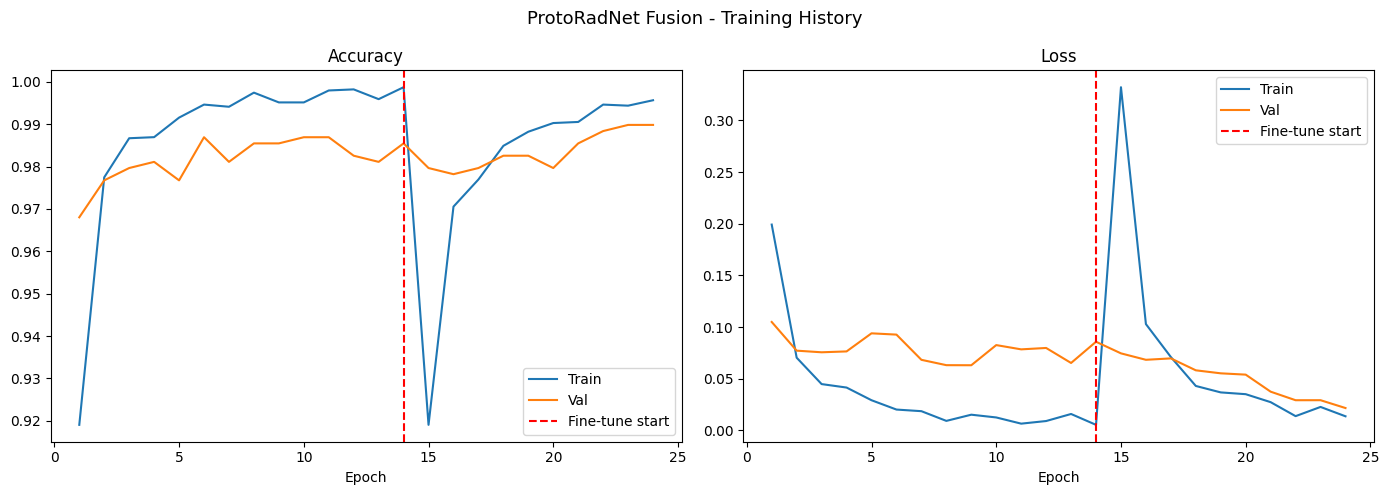

In [25]:
try:
    history_data = history.history
    history_ft_data = fine_tune_history.history
except NameError:
    with open('training_history.json', 'r') as f:
        full_history = json.load(f)

    history_data = {
        'accuracy': full_history['train_accuracy'],
        'val_accuracy': full_history['train_val_accuracy'],
        'loss': full_history['train_loss'],
        'val_loss': full_history['train_val_loss']
    }
    history_ft_data = {
        'accuracy': full_history['fine_tune_accuracy'],
        'val_accuracy': full_history['fine_tune_val_accuracy'],
        'loss': full_history['fine_tune_loss'],
        'val_loss': full_history['fine_tune_val_loss']
    }

acc   = history_data['accuracy']     + history_ft_data['accuracy']
val   = history_data['val_accuracy'] + history_ft_data['val_accuracy']
loss  = history_data['loss']         + history_ft_data['loss']
vloss = history_data['val_loss']     + history_ft_data['val_loss']
epochs = range(1, len(acc) + 1)
ft_start = len(history_data['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, acc,  label='Train'); ax1.plot(epochs, val, label='Val')
ax1.axvline(ft_start, color='red', linestyle='--', label='Fine-tune start')
ax1.set_title('Accuracy'); ax1.legend(); ax1.set_xlabel('Epoch')

ax2.plot(epochs, loss, label='Train'); ax2.plot(epochs, vloss, label='Val')
ax2.axvline(ft_start, color='red', linestyle='--', label='Fine-tune start')
ax2.set_title('Loss'); ax2.legend(); ax2.set_xlabel('Epoch')

plt.suptitle('ProtoRadNet Fusion - Training History', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

Confusion Matrix & Classification Report

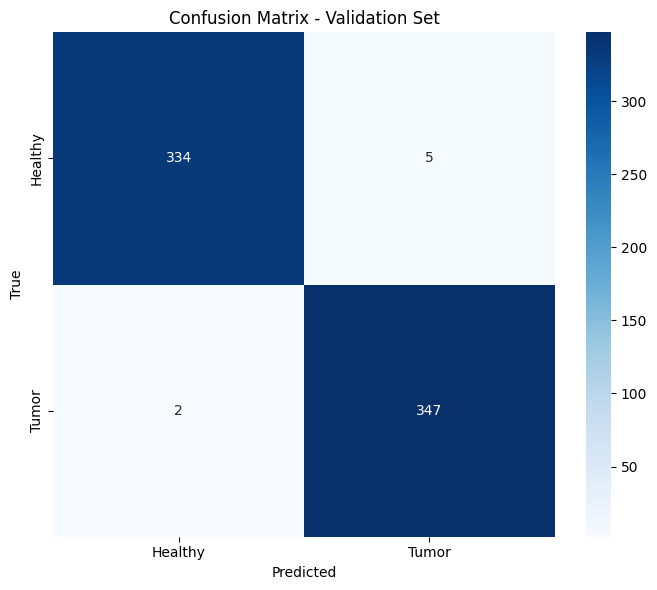

              precision    recall  f1-score   support

     Healthy       0.99      0.99      0.99       339
       Tumor       0.99      0.99      0.99       349

    accuracy                           0.99       688
   macro avg       0.99      0.99      0.99       688
weighted avg       0.99      0.99      0.99       688



In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

CLASS_NAMES = ['Healthy', 'Tumor']

y_true, y_pred = [], []
for (ct_b, xr_b), lbl in val_dataset.take(val_steps):
    preds = model.predict([ct_b, xr_b], verbose=0)
    y_true.extend(np.argmax(lbl,   axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - Validation Set')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

P-Value Hypothesis Testing

In [27]:
from scipy.stats import binomtest
import numpy as np

correct_predictions = np.sum(np.array(y_true) == np.array(y_pred))
total_predictions = len(y_true)

chance_accuracy = 1 / NUM_CLASSES

test_result = binomtest(
    k=correct_predictions,
    n=total_predictions,
    p=chance_accuracy,
    alternative='greater'
)

print("\n===== Hypothesis Testing: Model vs Random Chance =====")
print(f"Null Hypothesis H0       : Model accuracy is equal to random chance ({chance_accuracy:.2f})")
print("Alternative Hypothesis H1: Model accuracy is greater than random chance")
print(f"Correct Predictions      : {correct_predictions}/{total_predictions}")
print(f"Observed Accuracy        : {correct_predictions / total_predictions:.4f}")
print(f"P-value                  : {test_result.pvalue:.6f}")

alpha = 0.05

if test_result.pvalue < alpha:
    print("Result                   : Reject H0")
    print("Conclusion               : Model performs significantly better than random chance.")
else:
    print("Result                   : Fail to reject H0")
    print("Conclusion               : Not enough evidence that the model is better than random chance.")



===== Hypothesis Testing: Model vs Random Chance =====
Null Hypothesis H0       : Model accuracy is equal to random chance (0.50)
Alternative Hypothesis H1: Model accuracy is greater than random chance
Correct Predictions      : 681/688
Observed Accuracy        : 0.9898
P-value                  : 0.000000
Result                   : Reject H0
Conclusion               : Model performs significantly better than random chance.


## Interpretability - Highlight the Region
We extract the patch attention scores and overlay them as a heatmap on the original image, showing exactly **which spatial region** the model focused on. This maps directly to the *Highlight the Region* box in your pipeline.

       ProtoRadNet - DIAGNOSIS REPORT
  Scan Type   : MRI
  Prediction  : Tumor
  Status      : Brain Tumor Detected
  Confidence  : 99.6%
  Note        : Single-modality prediction; fusion model is best with both CT and MRI

  All Class Probabilities:
    Healthy     :   0.4%  
    Tumor       :  99.6%  ############################# <


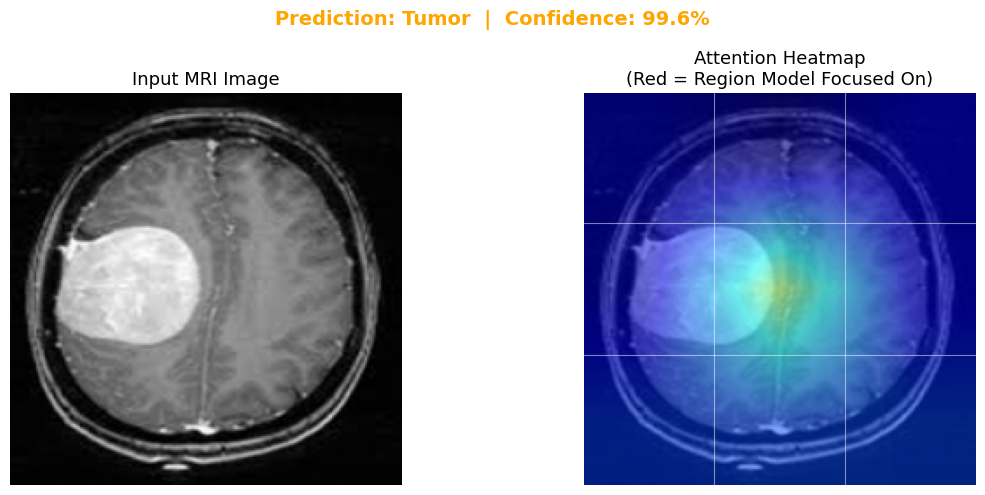

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


attn_model = Model(
    inputs  = [ct_input, xray_input],
    outputs = model.get_layer('patch_attention').output,
    name    = 'attention_extractor'
)

CLASS_NAMES = ['Healthy', 'Tumor']
IMG_SIZE    = 224


def load(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE))


def overlay(img, attn_grid):
    hm = cv2.resize(attn_grid.astype(np.float32), (IMG_SIZE, IMG_SIZE))
    hm = np.uint8(255 * hm)
    hm = cv2.applyColorMap(hm, cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
    return (0.5 * img + 0.5 * hm).astype(np.uint8)


def predict_scan(image_path, image_type):
    """
    Predict from a single brain CT or MRI image.

    Parameters:
        image_path : path to the image file
        image_type : 'ct', 'mri', or 'xray'
    """


    image_type = image_type.lower()
    img      = load(image_path)
    img_norm = (img / 255.0).astype(np.float32)[np.newaxis, ...]   # shape: (1, 224, 224, 3)
    missing_modality = np.zeros_like(img_norm)


    if image_type == 'ct':
        ct_in, xray_in = img_norm, missing_modality
        attn_slice = slice(0, 9)
    elif image_type in ('mri', 'xray'):
        ct_in, xray_in = missing_modality, img_norm
        attn_slice = slice(9, 18)
        image_type = 'mri'
    else:
        raise ValueError("image_type must be 'ct', 'mri', or 'xray'")


    probs      = model.predict([ct_in, xray_in], verbose=0)[0]
    pred_idx   = int(np.argmax(probs))
    pred_label = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx] * 100

 
    attn_raw = attn_model.predict([ct_in, xray_in], verbose=0)[0, :, 0]
 
    attn_grid = attn_raw[attn_slice].reshape(3, 3)

 
    if pred_label == 'Healthy':
        status = 'No Tumor Detected'
        color  = 'green'
    else:
        status = 'Brain Tumor Detected'
        color  = 'orange'

 
    print("=" * 50)
    print("       ProtoRadNet - DIAGNOSIS REPORT")
    print("=" * 50)
    print(f"  Scan Type   : {image_type.upper()}")
    print(f"  Prediction  : {pred_label}")
    print(f"  Status      : {status}")
    print(f"  Confidence  : {confidence:.1f}%")
    print("  Note        : Single-modality prediction; fusion model is best with both CT and MRI")
    if confidence < 60:
        print("  Low confidence - use both CT and MRI when possible")
    print()
    print("  All Class Probabilities:")
    for i, name in enumerate(CLASS_NAMES):
        bar    = '#' * int(probs[i] * 30)
        marker = ' <' if i == pred_idx else ''
        print(f"    {name:<12}: {probs[i]*100:5.1f}%  {bar}{marker}")
    print("=" * 50)


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.imshow(img)
    ax1.set_title(f'Input {image_type.upper()} Image', fontsize=13)
    ax1.axis('off')

    ax2.imshow(overlay(img, attn_grid))
    ax2.set_title('Attention Heatmap\n(Red = Region Model Focused On)', fontsize=13)
    ax2.axis('off')


    for k in range(1, 3):
        ax2.axhline(y=k * IMG_SIZE // 3, color='white', linewidth=0.8, alpha=0.5)
        ax2.axvline(x=k * IMG_SIZE // 3, color='white', linewidth=0.8, alpha=0.5)

    plt.suptitle(
        f'Prediction: {pred_label}  |  Confidence: {confidence:.1f}%',
        fontsize=14, color=color, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('diagnosis_result.png', dpi=150)
    plt.show()


def predict_pair(ct_image_path, mri_image_path):
    """Predict using both CT and MRI inputs, matching the fusion model training setup."""
    ct_img = load(ct_image_path)
    mri_img = load(mri_image_path)

    ct_in = (ct_img / 255.0).astype(np.float32)[np.newaxis, ...]
    mri_in = (mri_img / 255.0).astype(np.float32)[np.newaxis, ...]

    probs = model.predict([ct_in, mri_in], verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx] * 100
    status = 'No Tumor Detected' if pred_label == 'Healthy' else 'Brain Tumor Detected'

    print("=" * 50)
    print("       ProtoRadNet - DIAGNOSIS REPORT")
    print("=" * 50)
    print("  Scan Type   : CT + MRI")
    print(f"  Prediction  : {pred_label}")
    print(f"  Status      : {status}")
    print(f"  Confidence  : {confidence:.1f}%")
    print()
    print("  All Class Probabilities:")
    for i, name in enumerate(CLASS_NAMES):
        bar = '#' * int(probs[i] * 30)
        marker = ' <' if i == pred_idx else ''
        print(f"    {name:<12}: {probs[i]*100:5.1f}%  {bar}{marker}")
    print("=" * 50)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(ct_img)
    ax1.set_title('Input CT Image', fontsize=13)
    ax1.axis('off')
    ax2.imshow(mri_img)
    ax2.set_title('Input MRI Image', fontsize=13)
    ax2.axis('off')
    plt.suptitle(
        f'Prediction: {pred_label}  |  Confidence: {confidence:.1f}%',
        fontsize=14,
        color='green' if pred_label == 'Healthy' else 'orange',
        fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('diagnosis_pair_result.png', dpi=150)
    plt.show()


predict_scan(
    image_path = r'Y1.jpg',
    image_type = 'mri'
)


# predict_scan(
#     image_path = r'C:\Users\adith\Desktop\xray.png',
#     image_type = 'xray'
# )